# **Introduction to Jupyter Notebooks**
Most of the exercises in this class will be run on Jupyter Notebooks. This exercise will be about using Jupyter Notebooks. It has been adapted from [Lab 01 of IIBM3202 Molecular Modeling and Simulation](https://github.com/pb3lab/ibm3202/blob/master/tutorials/lab01_intro.ipynb) from the Institute for Biological and Engineering at Pontificia Universidad Catolica de Chile, which is based on Google Colab.

This exercise is intended to help you achieve the following learning objectives:
* Use Jupyter Notebooks to run python computer code and to annotate results.

Assuming that you are reading this Notebook on Github, you will need to download it to your account on SDSC Expanse. To do that, log onto the Expanse User Portal, select *Shell*, and paste the following commands into the terminal:

```bash
mkdir -p ~/exercises
cd ~/exercises
curl -L -o 01-Jupyter_Notebooks.ipynb https://raw.githubusercontent.com/daveminh/Chem456-2026S/refs/heads/main/exercises/01-Jupyter_Notebooks.ipynb

```

The exercise will be graded based on submitting your answers to the questions after ```-->``` on Canvas.

# Part 1. Jupyter installation on SDSC Expanse

First, we need to install Jupyter on your account on SDSC Expanse. 

## 1) Log onto the Expanse User Portal → *Shell*.

## 2) Start an interactive CPU job (recommended for installs)

```bash
srun --partition=shared --account=iit130 --nodes=1 --ntasks=1 --cpus-per-task=4 --mem=8G --time=01:00:00 --pty bash
```

If your job waits in the queue too long, try the `debug` partition for 30 minutes.

## 3) Install Miniconda into your home directory (one time)

```bash
cd ~
# Download the installer
curl -L -o Miniconda3-latest-Linux-x86_64.sh https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
# Run the installer (can take a while)
bash Miniconda3-latest-Linux-x86_64.sh -b -p "$HOME/miniconda3"
# Enable conda in your current shell
source "$HOME/miniconda3/etc/profile.d/conda.sh"
# Verify that conda is installed. It should print a conda version number (e.g., `conda 24.x` or `conda 25.x`).
conda --version
```

## 4) Create and register a conda environment

We’ll use Python 3.11 in an environment named `visualization`. 
Among other packages, this environment will include:
* [jupyterlab](https://jupyter.org/), which provides a user interface that we will use in this exercise and throughout the class.
* [openbabel](https://openbabel.org/), to speak many languages of chemical data.
* [prody](http://www.bahargroup.org/prody/), for the manipulation and retrieval of protein structures and sequences.
* [nglview](https://github.com/nglviewer/nglview), which allows for molecular visualization in Jupyter notebooks.
We will use this environment for several exercises and create additional environments when needed.

To create this environment, paste the following commands in to the terminal:
```bash
# Install the mamba package manager, which is faster than conda
conda install -c conda-forge mamba -y
```
After you run this command, conda will likely ask you to accept terms of service. If so, run the commands to accept the terms and then run the `conda install -c conda-forge mamba -y` command again.

After you have installed mamba, create the environment.
```bash
# Create the environment
mamba create -n visualization -c conda-forge biopython jupyterlab notebook zlib openbabel prody ipykernel IPython ipywidgets matplotlib nglview=4.0.0 apbs -y
```

If you have problems creating the environment, you may need to remove it using `mamba env remove --name visualization` and install it again.

To register the kernel so it appears in JupyterLab, paste the following commands into the terminal:
```bash
conda activate visualization
python -m ipykernel install --user --name visualization --display-name "Python (visualization)"
```

Once these commands are complete, you may end the interactive CPU job with the `exit` command.

## 5) Start a JupyterLab session with galyleo

JupyterLab is an integrated environment that allows users to manage Jupyter Notebooks and other files. To start a JupterLab session, paste one of the following into your shell on Expanse. You can do this from the login node (you don't need an interactive job).

### In-class (debug partition, 30 minutes)

```bash
/cm/shared/apps/sdsc/galyleo/galyleo launch --account iit130 --partition debug --cpus 2 --memory 4 --time-limit 00:30:00 --interface lab --conda-env visualization --conda-init "$HOME/miniconda3/etc/profile.d/conda.sh"
```

### Homework (shared partition, 4 hours)
```bash
/cm/shared/apps/sdsc/galyleo/galyleo launch --account iit130 --partition shared --cpus 4 --memory 8 --time-limit 04:00:00 --interface lab --conda-env visualization --conda-init "$HOME/miniconda3/etc/profile.d/conda.sh"
```

After you run `galyleo launch`, you should see a **tokenized HTTPS URL** like ```https://<words>.expanse-user-content.sdsc.edu?token=<...>```. Copy/paste the **entire URL** into your browser. Do not share this URL — the token grants access to your session. From this session, you can navigate to the ```exercises``` folder and open this notebook in Jupyter.

## Troubleshooting

* Conda is slow / install fails. Ensure you’re doing installs in an **interactive compute job** (Step 1), not on a login node. Install fewer packages at once.

* Galyleo job exits immediately / you get a documentation page. This usually means the job failed before Jupyter started.

1) Check recent jobs:
```bash
sacct -u $USER --format=JobID,JobName%30,State,ExitCode,Elapsed -S today
```

2) Check galyleo debug files (generated scripts and logs):
```bash
ls -lt ~/.galyleo | head
```

* **Wrong account/project:** confirm `iit130` appears in `module load sdsc; expanse-client user -r expanse`.

* **Environment confusion:** run `echo $CONDA_DEFAULT_ENV` and `which python`.

## References
- SDSC Expanse User Guide: https://www.sdsc.edu/systems/expanse/user_guide.html
- Anaconda Miniconda install docs: https://www.anaconda.com/docs/getting-started/miniconda/install
- Conda Linux install docs: https://docs.conda.io/projects/conda/en/stable/user-guide/install/linux.html
- IPython kernel install docs: https://ipython.readthedocs.io/en/stable/install/kernel_install.html
- SDSC galyleo documentation: https://hpc-training.sdsc.edu/galyleo/


# Part 2. Introduction to Jupyter Notebooks

## What are Jupyter Notebooks? 🤔

Jupyter Notebooks allow you to write and execute python code in your browser.

* Python is a programming language commonly used in scientific computing.
* Interactive python (IPython) is an interface to run Python interactively, allowing one to enter and execute code snippets opposed to complete scripts.
* IPython Notebooks (ipynb) include the results of code executions and annotations.
* IPython Notebooks were generalized to Jupyter Notebooks to promote language agnosticism. The original IPython Notebook was designed exclusively for the Python programming language, but the creators realized the utility of the notebook format could extend to other scientific computing languages.

We will access Jupyter Notebooks using JupyterLab, a more powerful, flexible, and integrated development environment. It enables users to manage complex projects involving multiple file types and tools within a single, unified workspace.

After you have opened this notebook in JupyterLab, notice that at your left you have three icons. The first one is a File Explorer for your account on SDSC Expanse. The third one looks like this:

><img src="https://upload.wikimedia.org/wikipedia/commons/b/bb/Summary_icon.svg" width="100">

and corresponds to the Table of Contents of this tutorial.

## The central concept of Jupyter Notebooks: Cells

A notebook is a list of cells. Cells contain either explanatory text or executable code and its output.

* Click a cell to select it. 
* Double-click a cell to edit it. 
* Use **Shift+Enter** to execute it.


**Adding and moving cells**

You can add a new cell by using the buttons with a **+** on the top right of a selected cell. You can also add a cell below the currently selected cell by using the **+** button in the toolbar above the notebook.

The toolbar also has buttons to copy and paste cells. To select all cells between two cells, click on the first and then hold **Shift** while clicking the second.

You can move a cell (or multiple cells) by clicking on the up and down arrows on the top right of the selected cell(s).

Try moving this cell around. Also try selecting a few cells.

## Markdown cells


Jupyter Notebooks have three types of cells: Markdown, code, and raw. Markdown cells are formatted using a simple markup language called **markdown**, based on [the original](https://daringfireball.net/projects/markdown/syntax) markdown project. This is a **Markdown cell**. You can **double-click** to edit this cell and see its source.

### Markdown ⌨️




You can also use tags to format your text. The following are examples of markdown text formats. Each word/phrase is shown in the desired format, and the tags around it are those required to achieve each specific format.

**Text Formats:**

\**italics*\* or \__italics__

**\*\*bold\*\***

\~\~~~strikethrough~~\~\~

\``monospace`\`

**Indentations:**

No indent
>\>One level of indentation
>>\>\>Two levels of indentation

**An ordered list:**
1. 1\. One
1. 1\. Two
1. 1\. Three

**An unordered list:**
* \* One
* \* Two
* \* Three



### Math 🧮 & Equations ✏️



You can also add math to Markdown cells using [$\LaTeX$](http://www.latex-project.org/)
to be rendered by [MathJax](https://www.mathjax.org). Just place the statement
within a pair of **`$`** signs. For example `$\sqrt{3x-1}+(1+x)^2$` becomes
$\sqrt{3x-1}+(1+x)^2.$

Also, if you double the **`$`** tags in your $\LaTeX$ equations, you can set the contents off on its own centered line. For example, `$$y = 0.1 x$$` renders the following equation: $$y = 0.1 x$$

### Tables 📍



Tables:
```
First column name | Second column name
--- | ---
Row 1, Col 1 | Row 1, Col 2
Row 2, Col 1 | Row 2, Col 2
```

becomes:

>First column name | Second column name
>--- | ---
>Row 1, Col 1 | Row 1, Col 2
>Row 2, Col 1 | Row 2, Col 2

Horizontal rule done with three dashes (\-\-\-):

---


### Gifs 😱

YES! you can add animated gifs

<img src='https://media.giphy.com/media/3o72F8t9TDi2xVnxOE/giphy.gif'/>


## Code cells

Below is a **code cell**.

* Type **Cmd/Ctrl+Enter** to run the cell in place;
* Type **Shift+Enter** to run the cell and move focus to the next cell (adding one if none exists); or

There are additional options for running some or all cells in the **Kernel** menu.

After you run a cell, a number will appear that indicates the order in which the cell was run.

In [ ]:
W = 'Tryptophan'
C = 'Cysteine'
W,C

# Part 3. Introduction to Python 🐍 

### Before you start

**What is Python?**
Python is an interpreted, object-oriented, high-level programming language with dynamic semantics. Its high-level built in data structures, combined with dynamic typing and dynamic binding, make it very attractive for Rapid Application Development, as well as for use as a scripting or glue language to connect existing components together. Python's simple, easy to learn syntax emphasizes readability and therefore reduces the cost of program maintenance. Python supports modules and packages, which encourages program modularity and code reuse. The Python interpreter and the extensive standard library are available in source or binary form without charge for all major platforms, and can be freely distributed.

This notebook will not be a comprehensive Python tutorial. For that, I recommend [Codeacademy](https://www.codecademy.com/learn/learn-python). Rather it will demonstrate some key concepts, including dynamic typing and modules.


In [ ]:
# In order to "print" in python we use the print() function
print("Hello world!")

### Variables and data types


In [ ]:
# We define a variable by using an equal sign
a=1
print(a)

Note that we did not need to introduce the variable `a` in any way. No type was given for the variable. Python automatically detected that the type of `a` must be `int` (an integer). We can query the type of a variable with the builtin function `type`:

In [ ]:
type(a)

Note also that the type of a variable is not fixed:

In [ ]:
a="some text"
type(a)

In Python the type of a variable is not attached to the name of the variable, like in C for instance, but instead with the actual value. This is called dynamic typing.

![typing.svg](https://github.com/csmastersUH/data_analysis_with_python_2020/blob/master/typing.svg?raw=1)

### Expressions
An *expression* is a piece of Python code that results in a value. It consists of values combined together with *operators*. Values can be literals, such as `1`, `1.2`, `"text"`, or variables. Operators include arithmetics operators, comparison operators, function call, indexing, attribute references, among others. Below there are a few examples of expressions:

```
1+2
7/(2+0.1)
a
cos(0)
mylist[1]
c > 0 and c !=1
(1,2,3)
a<5
obj.attr
(-1)**2 == 1
```

<div class="alert alert-warning">Note that in Python the operator `//` performs integer division and operator `/` performs float division. The `**` operator denotes exponentiation. These operators might therefore behave differently than in many other common languages.</div>

As another example the following expression computes the kinetic energy of a non-rotating object:
`0.5 * mass * velocity**2`

In [ ]:
# --> Write an python expression for two to the power of three

### Modules 📦

#### • Using modules

Let’s say that we need to use the cosine function.
This function, and many other mathematical functions are
located in the `math` module.
To tell Python that we want to access the features offered by
this module, we can give the statement `import math`.
Now the module is loaded into memory.
We can now call the function like this:
```python
math.cos(0)
1.0
```

Note that we need to include the module name where the `cos`
function is found.
This is because other modules may have a function (or other
attribute of a module) with the same name.
This usage of different namespace for each module prevents
name clashes. For example, functions `gzip.open`, `os.open` are not to be confused
with the builtin `open` function.

In [ ]:
# --> Write python code using the math module to calculate the cosine of π (Hint: π is available as math.pi)

#### • Breaking the namespace

If the cosine is needed a lot, then it might be tedious to
always specify the namespace, especially if the name of the
namespace/module is long.
For these cases there is another way of importing modules.
Bring a name to the current scope with
`from math import cos` statement.
Now we can use it without the namespace specifier: `cos(1)`.

Several names can be imported to the current scope with
`from math import name1, name2, ...`
Or even all names of the module with `from math import *`
The last form is sensible only in few cases, normally it just
confuses things since the user may have no idea what names
will be imported.

#### • Module lookup

When we try to import a module `mod` with the import
statement, the lookup proceeds in the following order:

* Check if it is a builtin module
* Check if the file `mod.py` is found in any of the folders in
the list `sys.path`. The first item in this list is the current
folder

When Python is started, the `sys.path` list is initialised with
the contents of the `PYTHONPATH` environment variable

#### • Module hierarchy

The standard library contains hundreds of modules.
Hence, it is hard to comprehend what the library includes.
The modules therefore need to be organised somehow.
In Python the modules can be organised into hierarchies using
*packages*.
A package is a module that can contain other packages and
modules.
For example, the `numpy` package contains subpackages `core`,
`distutils`, `f2py`, `fft`, `lib`, `linalg`, `ma`, `numarray`, `oldnumeric`,
`random`, and `testing`.
And package `numpy.linalg` in turn contains modules `linalg`,
`lapack_lite` and `info`.

#### • Importing from packages

The statement `import numpy` imports the top-level package `numpy`
and its subpackages. 

* `import numpy.linalg` imports the subpackage only, and
* `import numpy.linalg.linalg` imports the module only

If we want to skip the long namespace specification, we can
use the form

```python
from numpy.linalg import linalg
```

or

```python
from numpy.linalg import linalg as lin
```

if we want to use a different name for the module. The following command imports the function `det` (computes the determinant of a matrix) from the module linalg, which is contained in a subpackage linalg, which belongs to package numpy:
```python
from numpy.linalg.linalg import det
```

Had we only imported the top-level package `numpy` we would have to refer to the `det` function with the full name `numpy.linalg.linalg.det`.

Here's a recap of the module hierarchy:

```
numpy    package
  .
linalg   subpackage
  .
linalg   module
  .
 det     function
```

In [ ]:
import numpy 
# --> Write python code to using numpy.linalg.det to compute the determinant of a 2x2 identity matrix

#### • Correspondence between folder and module hierarchies

The packages are represented by folders in the filesystem.
The folder should contain a file named `__init__.py` that
makes up the package body. This handles the initialisation of
the package.
The folder may contain also further folders
(subpackages) or Python files (normal modules).

```
a/
    __init__.py
    b.py
    c/
        __init__.py
        d.py
        e.py
```
![package.svg](https://github.com/csmastersUH/data_analysis_with_python_2020/blob/master/package.svg?raw=1)

#### • Contents of a module

Suppose we have a module named `mod.py`.
All the assignments, class definitions with the `class` statement,
and function definitions with `def` statement will create new
attributes to this module.
Let’s import this module from another Python file using the
`import mod` statement.
After the import we can access the attributes of the module
object using the normal dot notation: `mod.f()`,
`mod.myclass()`, `mod.a`, etc.
Note that Python doesn’t really have global variables that are
visible to all modules. All variables belong to some module
namespace.

One can query the attributes of an object using the `dir` function. With no
parameters, it shows the attributes of the current module. Try executing `dir()` in
an IPython shell or in a Jupyter notebook! After that, define the following attributes, and try running `dir()`
again:

```python
a=5
def f(i):
    return i + 1
```

The above definitions created a *data attribute* called `a` and a *function attribute* called `f`.
We will talk more about attributes next week when we will talk about objects.

Just like other objects, the module object contains its
attributes in the dictionary `modulename.__dict__`
Usually a module contains at least the attributes `__name__` and
`__file__`. Other common attributes are `__version__`,
`__author__` and `__doc__` , which contains the docstring of the
module.
If the first statement of a file is a string, this is taken as the
docstring for that module. Note that the docstring of the module really must be the first non-empty non-comment line.
The attribute `__file__` is always the filename of the module.

The module attribute `__name__` has value `“__main__”` if we in are the main program,
otherwise some other module has imported us and name
equals `__file__`.

In Python it is possible to put statements on the top-level of our module `mod` so that they don't belong to any function. For instance like this:

```python
for _ in range(3):
    print("Hello")
```

But if somebody imports our module with `import mod`, then all the statements at the top-level will be executed. This may be surprising to the user who imported the module. The user will usually say, explicitly when he/she wants to execute some code from the imported module.

It is better style to put these statements inside some function. If they don't fit in any other function, then you can use, for example, the function named `main`, like this:

```python
def main():
    for _ in range(3):
        print("Hello")

if __name__ == "__main__":    # We call main only when this module is not being imported, but directly executed
    main()                    # for example with 'python3 mod.py'
```

You probably have seen this mechanism used in the exercise stubs.
Note that in Python the `main` has no special meaning, it is just our convention to use it here.
Now if somebody imports `mod`, the `for` loop won't be automatically executed. If we want, we can call it explicitly with `mod.main()`. 

```python
for _ in range(3):
    print("Hello")
```

## Representing your data 📊 📈

The visualization of our results is as important as the process of analysis.There are several Python libraries for data visualization, but we will focus on one of the most used and essential: *matplotlib*. [Matplotlib](https://matplotlib.org/stable/index.html) is highly customizable and is compatible with a great number of files formats as *png, tiff, jpeg, etc*. Let's see some examples!



First we need to import the `matplotlib.pyplot` module and the complete module with shorthands.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

We'll create a simple example to illustrate how to use the `matplotlib.pyplot`. Let's see what happens with our Python programming skills if we spend time doing the exercises of the Appendix in IBM3202 tutorials.

In [ ]:
# Data
time = [0, 10, 20, 300]
python_level = [0, 1, 2, 30]

plt.plot(time, python_level)
plt.xlabel('Time (hr)')
plt.ylabel('Python programming level')

We can change the style of the plots easily with the `plt.style.use` method (you can check the available styles [here](https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html)). Additionally, the plots can be saved to a file with the function `savefig`. The *format* will be infered from the filename and the size of the plot can be change with the *dpi*, *width* and *height* arguments. 




In [ ]:
plt.style.use('dark_background')

plt.plot(time, python_level)
plt.xlabel('Time (hr)')
plt.ylabel('Python programming level')

# plt.savefig('First_plot.png', dpi = 100)

As you can see, we have added all the elements of the plot just using methods included in the `Matplotlib.pyplot` module. The `plot` function allow us to visualize the relationship of the variables with lines and markers, but there is a lot of options available (histograms, barplots, boxplots, etc). Plots are highly customizable. We can change the color, line width, transparency, line style, etc, just adding a few parameters to the function call. If you are passionate about data visualization, we recommend you to review the Matplotlib documentation (you can find it [here](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)) to get the most benefit from this tool.

In [ ]:
fig, axs = plt.subplots(2, 2, sharex=True)
axs[0, 0].plot(time, python_level, linestyle = '--', color = 'darkred')
axs[0, 0].set_title('Plot 1')
axs[0, 1].plot(time, python_level, linestyle = '-', color = 'mediumaquamarine', linewidth = 2, marker = "*", markersize = 16)
axs[0, 1].set_title('Plot 2')
axs[1, 0].plot(time, python_level, linestyle = ':', color = 'darkgreen', marker = "d", markersize = 12, alpha = 0.5)
axs[1, 0].set_title('Plot 3')
axs[1, 1].plot(time, python_level, linestyle = '', color = 'olivedrab', marker = '$\\phi$', markersize = 15)
axs[1, 1].set_title('Plot 4')


Ther are [a number of other common data visualization packages](https://www.lucentinnovation.com/resources/it-insights/python-data-visualization-libraries?st_source=ai_mode) including Seaborn (improved default aesthetics and integration with pandas DataFrame) and altair (interactive). 

Here is a high-level comparison of four packages (from Google Gemini):
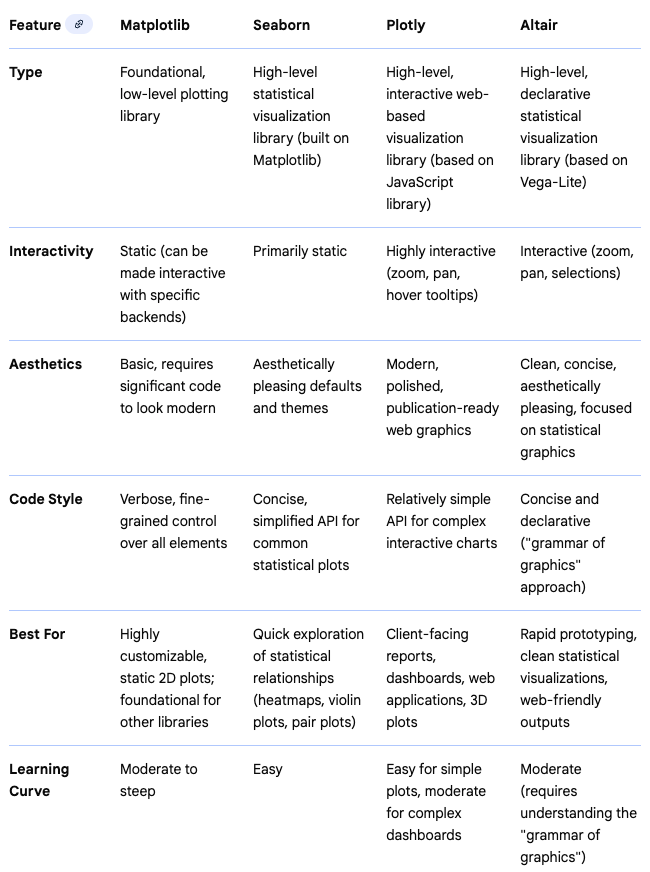

To use another one besides matplotlib, you will need to install it into your conda environment using mamba.


# Part 4. Using the bash shell in Jupyter Notebooks 🏃🏃‍♀️🏃‍♂️

### IPython and Shell Commands

*This part of this tutorial contains an excerpt from the [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas; the content is available [on GitHub](https://github.com/jakevdp/PythonDataScienceHandbook).*

*The text is released under the [CC-BY-NC-ND license](https://creativecommons.org/licenses/by-nc-nd/3.0/us/legalcode), and code is released under the [MIT license](https://opensource.org/licenses/MIT). If you find this content useful, please consider supporting the work by [buying the book](http://shop.oreilly.com/product/0636920034919.do)!*

When working interactively with the standard Python interpreter, one of the frustrations is the need to switch between multiple windows to access Python tools and system command-line tools. IPython bridges this gap, and gives you a syntax for executing shell commands directly from within the IPython terminal.

The magic happens with the exclamation point: anything appearing after ``!`` on a line will be executed not by the Python kernel, but by the system command-line.

The following assumes you're on a Unix-like system, like this Jupyter Notebooks cloud instance.
Some of the examples that follow will fail on Windows, which uses a different type of shell by default.

If you're unfamiliar with shell commands, I'd suggest reviewing the [Shell Tutorial](http://swcarpentry.github.io/shell-novice/) put together by the always excellent Software Carpentry Foundation.

### Quick Introduction to the Shell



A full intro to using the shell / terminal / command-line is well beyond the scope of this exercise, but for the uninitiated we will offer a quick introduction here.

>The shell is a way to interact textually with your computer.
Ever since the mid 1980s, when Microsoft and Apple introduced the first versions of their now ubiquitous graphical operating systems, most computer users have interacted with their operating system through familiar clicking of menus and drag-and-drop movements.
But operating systems existed long before these graphical user interfaces, and were primarily controlled through sequences of text input: at the prompt, the user would type a command, and the computer would do what the user told it to.
Those early prompt systems are the precursors of the shells and terminals that most active data scientists still use today.

Someone unfamiliar with the shell might ask why you would bother with this, when many results can be accomplished by simply clicking on icons and menus.
A shell user might reply with another question: why hunt icons and click menus when you can accomplish things much more easily by typing?
While it might sound like a typical tech preference impasse, when moving beyond basic tasks it quickly becomes clear that the shell offers much more control of advanced tasks, though admittedly the learning curve can intimidate the average computer user.

As an example, the following are the most common bash commands and a short description:

```bash
cd: change directory
ls: list
mv: move
cp: copy
mkdir: make new directory
history: terminal history (i.e. history of the commands you have executed) help: command list & help
echo: outputs to terminal
expr: evaluate expression and outputs to terminal
wc: word count
cat: “concatenate” streams all input to the terminal
sed: “stream editor” edits input (most importantly substitute) and outputs to the terminal 
grep: “Global regular expression print”, searches a given expression and outputs to terminal 
awk: pattern scanning & processing language
```

Notice that all of this is just a compact way to do familiar operations (navigating a directory structure, creating a directory, moving a file, etc.) by typing commands rather than clicking icons and menus.
Note that with just a few commands (``pwd``, ``ls``, ``cd``, ``mkdir``, and ``cp``) you can do many of the most common file operations.
It's when you go beyond these basics that the shell approach becomes really powerful.

### Shell Commands in Jupyter Notebooks



Any command that works at the bash command-line can be used in IPython by prefixing it with the ``!`` character.
For example, the ``ls``, ``pwd``, and ``echo`` commands can be run as follows:

```ipython
In [1]: !ls
01-Jupyter_Notebooks.ipynb

In [2]: !pwd
/home/daveminh/exercises

In [3]: !echo "printing from the shell"
printing from the shell
```
This can also be done in Jupyter Notebooks.

--> Write a code cell that lists all files and directories with `ls`, prints the working directory with `pwd`, and prints `Hello world` using `echo`

### Passing Values to and from the Shell


In [ ]:
directory = !pwd
print(directory)

Shell commands can not only be called from IPython, but can also be made to interact with the IPython namespace.
For example, you can save the output of any shell command to a Python list using the assignment operator:

```ipython
In [4]: contents = !ls

In [5]: print(contents)
['sample_data']

In [6]: directory = !pwd

In [7]: print(directory)
['/content']
```

Try them out yourself!

In [ ]:
# Try the commands indicated above

Note that these results are not returned as lists, but as a special shell return type defined in IPython:

```ipython
In [8]: type(directory)
IPython.utils.text.SList
```

This looks and acts a lot like a Python list, but has additional functionality, such as
the ``grep`` and ``fields`` methods and the ``s``, ``n``, and ``p`` properties that allow you to search, filter, and display the results in convenient ways.
For more information on these, you can use IPython's built-in help features.

Communication in the other direction–passing Python variables into the shell–is possible using the ``{varname}`` syntax:

```ipython
In [9]: message = "hello from the other side (Python)"

In [10]: !echo {message}
hello from Python
```

The curly brackets contain the variable name, which is replaced by the variable's contents in the shell command.

In [ ]:
# Assign a string to a variable in python and print it using echo in bash

### Shell-Related Magic Commands

If you play with IPython's shell commands for a while, you might notice that you cannot use ``!cd`` to navigate the filesystem:

```ipython
In [11]: !pwd
/content/

In [12]: !cd ..

In [13]: !pwd
/content/
```



In the bash shell, `cd ..` means to change to the parent directory.

In [ ]:
# Try for yourself!

The reason is that shell commands in the notebook are executed in a temporary subshell.
If you'd like to change the working directory in a more enduring way, you can use the ``%cd`` magic command:

```ipython
In [14]: %cd ..
/
```

This is known as an ``automagic`` function, and this behavior can be toggled with the ``%automagic`` magic function.

Besides ``%cd``, other available shell-like magic functions are ``%cat``, ``%cp``, ``%env``, ``%ls``, ``%man``, ``%mkdir``, ``%more``, ``%mv``, ``%pwd``, ``%rm``, and ``%rmdir``, any of which can be used without the ``%`` sign if ``automagic`` is on.
This makes it so that you can almost treat the IPython prompt as if it's a normal shell:

This access to the shell from within the same terminal window as your Python session means that there is a lot less switching back and forth between interpreter and shell as you write your Python code.

In [ ]:
# Use !cd to change to the parent directory and return to the exercises directory
# List the directory after each !cd.

In [ ]:
# --> Use %cd to the parent directory and return to the exercises directory
#     List the directory after each %cd.

💡 Hint: You can use the %%bash at the beginning of your cell code instead of the `!` approach to active automagic for the whole cell code. Try it below!


In [ ]:
%%bash

This information and exercises should be sufficient for you to start using the bash shell commands more often. As with any other piece of software, it requires practice, but we are sure you will get used to it by the end of this course.

# Part 5. Ending the session

To end the JupyterLab session, you should click on `File->Shut Down`. Closing your browser tab does **not** necessarily stop the job. You can find your running jobs with `squeue -u $USER` and cancel a job with `scancel <JOBID>` (replace `<JOBID>`).

When you are done with this exercise, save the file in ~/exercises. Submit your answers to the questions after ```-->``` on Canvas.